## **SVM (Linear)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    roc_curve, auc,
)
import joblib


### Data loading and preparation

In [ ]:
# Load the  datasets
train_df = pd.read_csv('../train_coded.csv')
test_df = pd.read_csv('../test_coded.csv')

# Split features and labels
X_test_final = test_df.iloc[:, :-1]
y_test_final = test_df.iloc[:, -1]

X_train_full = train_df.iloc[:, :-1]
y_train_full = train_df.iloc[:, -1]

# Create a Validation Set from the Training Set (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=0.20,      
    random_state=42,     
    stratify=y_train_full 
)

# Using float32 to save memory
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test_final = X_test_final.astype('float32')

print("Data splitting completed:")
print(f" - Training Set: {X_train.shape}")
print(f" - Validation Set: {X_val.shape}")
print(f" - Final Test Set: {X_test_final.shape}")

Data splitting completed:
 - Training Set: (25584, 805)
 - Validation Set: (6396, 805)
 - Final Test Set: (7996, 805)


### Model Training

In [3]:
# Define the Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("svc", LinearSVC(class_weight="balanced", dual=False, max_iter=10000))
])

# Hyperparameter grid for C
param_grid = {
    "svc__C": [0.001, 0.01, 0.1, 1, 10]
}

# Configure Grid Search with weighted F1-score to handle potential class imbalance
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=1 
)

print("\nStarting Training (Grid Search)...")
grid.fit(X_train, y_train)

# Display Tuning Results
print("\n--- Tuning Results ---")
print(f"Best C parameter: {grid.best_params_}")
print(f"Best CV score (F1-weighted): {grid.best_score_:.4f}")

# Evaluation on the Validation Set
best_model = grid.best_estimator_
y_val_pred = best_model.predict(X_val)

print("\n--- Validation Results ---")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))


Starting Training (Grid Search)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

--- Tuning Results ---
Best C parameter: {'svc__C': 0.001}
Best CV score (F1-weighted): 0.6682

--- Validation Results ---
Validation Accuracy: 0.6725

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      1280
           1       0.67      0.59      0.63      1280
           2       0.64      0.68      0.66      1280
           3       0.72      0.72      0.72      1280
           4       0.70      0.71      0.70      1276

    accuracy                           0.67      6396
   macro avg       0.67      0.67      0.67      6396
weighted avg       0.67      0.67      0.67      6396



### Defining Class Names for Evaluation and Plotting

In [4]:
# Define the mapping from integer class to string label
class_labels = {
    0: 'BPD',
    1: 'bipolar',
    2: 'depression',
    3: 'anxiety',
    4: 'schizophrenia'
}

# Create a list of names in the correct order for plotting
class_names = [class_labels[i] for i in range(len(class_labels))]
print(f"Class Names: {class_names}")

Class Names: ['BPD', 'bipolar', 'depression', 'anxiety', 'schizophrenia']


### Classification report and confusion matrix


--- FINAL RESULTS ON TEST SET ---

Final Classification Report:
               precision    recall  f1-score   support

          BPD       0.67      0.66      0.66      1600
      bipolar       0.67      0.62      0.64      1600
   depression       0.64      0.70      0.67      1600
      anxiety       0.70      0.72      0.71      1600
schizophrenia       0.71      0.68      0.70      1596

     accuracy                           0.68      7996
    macro avg       0.68      0.68      0.68      7996
 weighted avg       0.68      0.68      0.68      7996



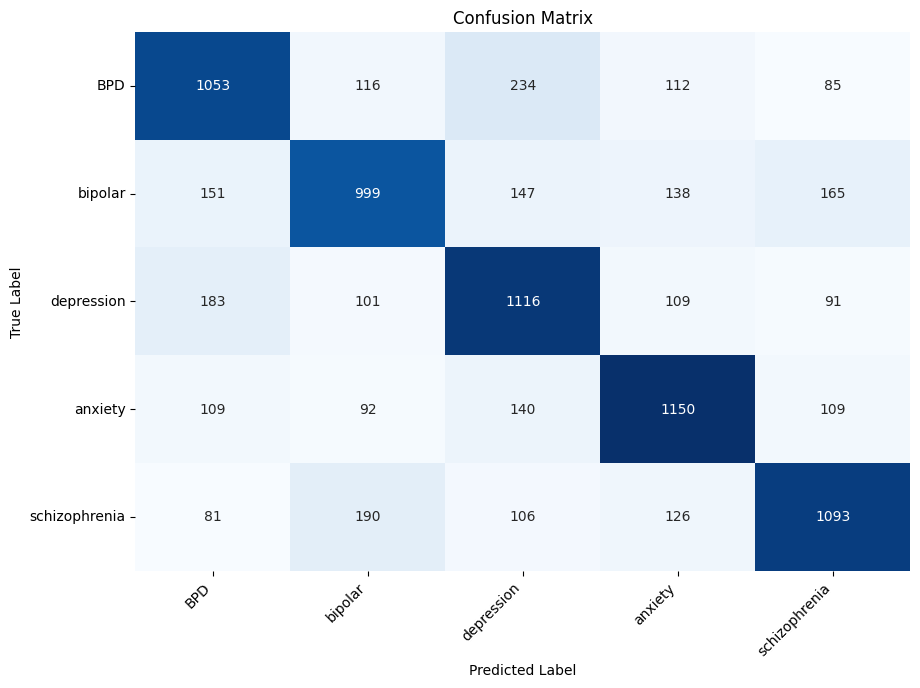

In [6]:
# Evaluation on the Final Test Set
print("\n--- FINAL RESULTS ON TEST SET ---")
y_test_pred = best_model.predict(X_test_final)

print("\nFinal Classification Report:")
print(classification_report(y_test_final, y_test_pred, target_names=class_names))

# Visualizing the Confusion Matrix
cm = confusion_matrix(y_test_final, y_test_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar=False)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) 

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### ROC curve

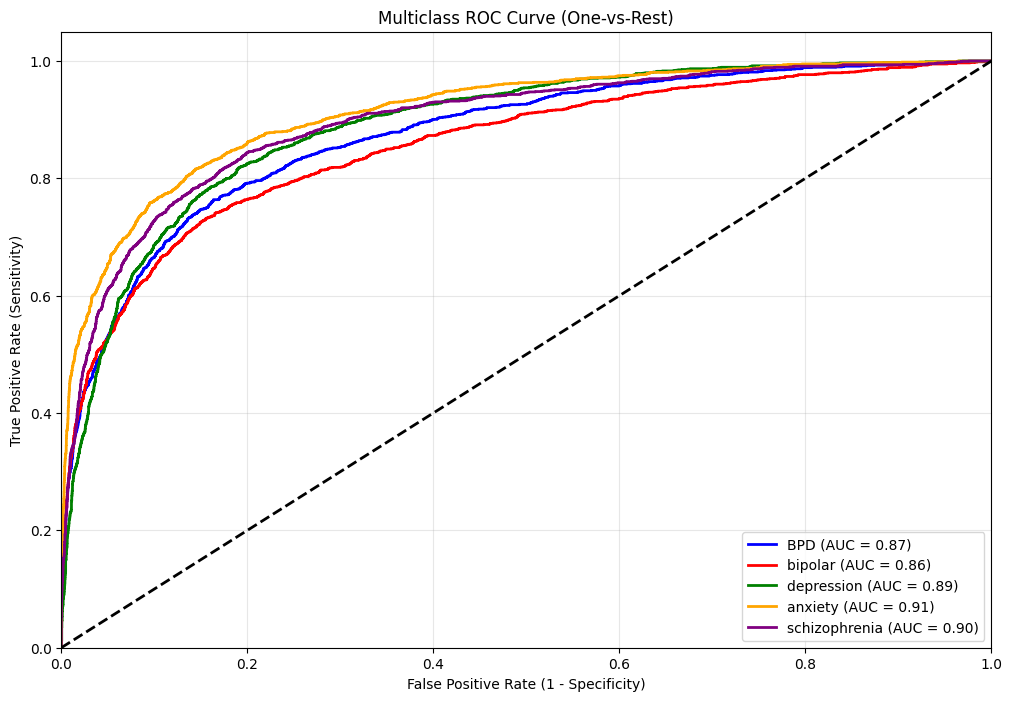

In [7]:
# Binarize the output labels for One-vs-Rest ROC
classes = np.unique(y_test_final)
n_classes = len(classes)
y_test_bin = label_binarize(y_test_final, classes=classes)

# Get decision scores and compute ROC curve/area for each class
y_score = best_model.decision_function(X_test_final)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting all ROC curves
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

for i, color in zip(range(n_classes), colors):
    label_text = f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=label_text)

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Performance metrics per class

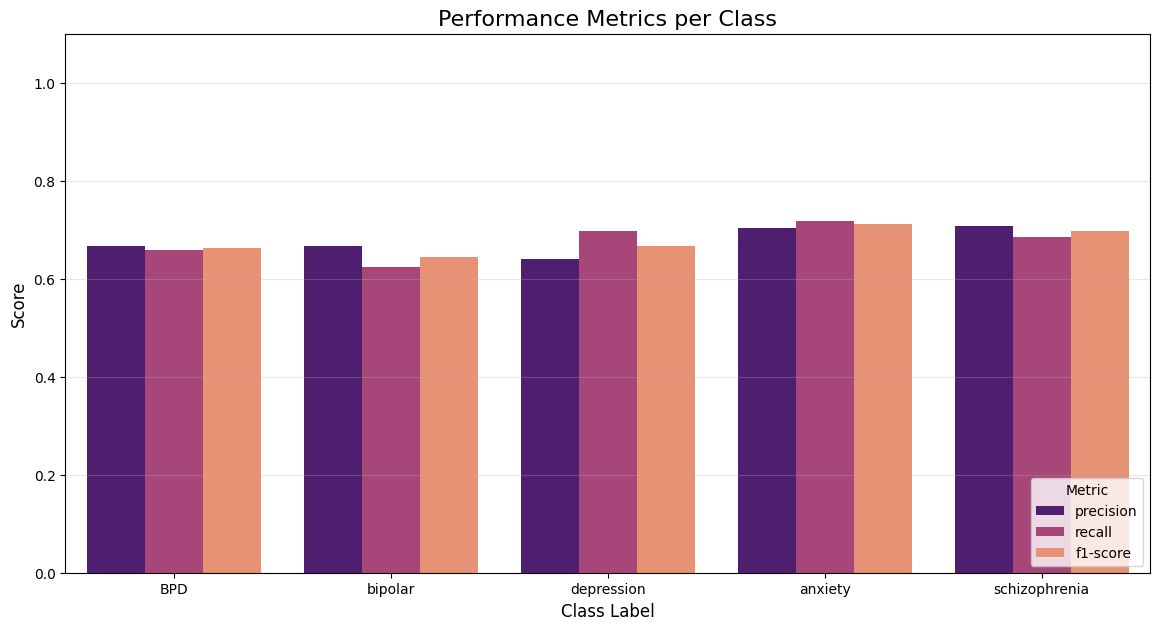

In [8]:
# Generate report as a dictionary
report_dict = classification_report(y_test_final, y_test_pred, output_dict=True)

# Convert to DataFrame and clean up
df_metrics = pd.DataFrame(report_dict).transpose()

# Remove aggregate rows to focus on classes only
rows_to_drop = ['accuracy', 'macro avg', 'weighted avg']
df_metrics_classes = df_metrics.drop(index=rows_to_drop, errors='ignore').copy()

# Replace the numeric index with class names
df_metrics_classes.index = df_metrics_classes.index.astype(float).astype(int).map(class_labels)

# Reshape data for Seaborn (Melting)
df_melted = df_metrics_classes[['precision', 'recall', 'f1-score']].reset_index()
df_melted = df_melted.melt(id_vars='index', var_name='Metric', value_name='Score')

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='index', y='Score', hue='Metric', palette='magma')

plt.title('Performance Metrics per Class', fontsize=16)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Metric', loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Saving the model

In [9]:
# Save the full Sklearn wrapper using Joblib
joblib.dump(best_model, "svm.pkl")
print("Full sklearn model wrapper saved to 'svm.pkl'")

Full sklearn model wrapper saved to 'svm.pkl'
